

# Mechanical Digital Twin Visualization — Upgraded Edition

This notebook simulates a mechanical digital twin with reproducible sensor data, fault injection, feature engineering, anomaly detection, frequency analysis, PCA-based health mapping, and sensor/network visualization.

**Improvements over the original version**
- deterministic simulation with a fixed random seed
- cleaner structure and reusable functions
- richer sensor model with degradation and fault windows
- engineered health features and anomaly scoring
- clearer plots and system architecture diagrams
- compact summary output for diagnostics


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Required packages

If a package is missing on your machine, install it once in your environment and rerun the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # pyright: ignore[reportMissingModuleSource]

from scipy.fft import rfft, rfftfreq
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import networkx as nx

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

## 1. Sensor data simulation

In [5]:
def simulate_digital_twin(n_samples: int = 2000, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    time = np.arange(n_samples)

    # Operatingdef load varies slowly across time
    load = 0.55 + 0.18 * np.sin(2 * np.pi * time / 700.0) + 0.05 * np.sin(2 * np.pi * time / 120.0)

    # Base rotation speed with small process noise
    rpm = 1500 + 60 * np.sin(2 * np.pi * time / 480.0) + rng.normal(0, 12, n_samples)

    # Gradual degradation after mid-life
    wear = np.clip((time - 1200) / 800, 0, 1)

    # Fault window with abrupt disturbance
    fault_window = ((time >= 1500) & (time <= 1650)).astype(int)

    pressure = 48 + 0.020 * rpm + 7.0 * load - 3.5 * wear + 4.5 * fault_window + rng.normal(0, 1.6, n_samples)
    flow = 0.58 * pressure - 0.8 * load + 1.8 * fault_window + rng.normal(0, 0.9, n_samples)
    temperature = 52 + 0.013 * rpm + 5.5 * load + 9.0 * wear + 4.0 * fault_window + rng.normal(0, 1.1, n_samples)
    vibration = (
        0.0016 * rpm
        + 0.55 * np.sin(2 * np.pi * time / 36.0)
        + 0.9 * wear
        + 2.0 * fault_window
        + rng.normal(0, 0.22, n_samples)
    )
    motor_current = 8 + 0.0025 * rpm + 1.2 * load + 1.4 * wear + 0.8 * fault_window + rng.normal(0, 0.35, n_samples)

    df = pd.DataFrame(
        {
            "time": time,
            "load": load,
            "rpm": rpm,
            "pressure": pressure,
            "flow": flow,
            "temperature": temperature,
            "vibration": vibration,
            "motor_current": motor_current,
            "wear": wear,
            "fault_window": fault_window,
        }
    )

    return df


df = simulate_digital_twin()
df.head()

,time,load,rpm,pressure,flow,temperature,vibration,motor_current,wear,fault_window
0,0,0.550000,1503.656605,81.200011,46.883890,74.820164,2.479243,12.480838,0.0,0
1,1,0.554232,1488.305566,80.580334,47.098904,74.337574,2.748791,12.700536,0.0,0
2,2,0.558458,1510.576031,82.815140,47.832004,75.659453,2.872515,11.931294,0.0,0
3,3,0.562668,1513.642366,82.614492,49.481219,75.439432,2.597617,12.359453,0.0,0
4,4,0.566857,1479.727735,79.314887,46.835957,71.069769,2.763781,12.669751,0.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           2000 non-null   int64  
 1   load           2000 non-null   float64
 2   rpm            2000 non-null   float64
 3   pressure       2000 non-null   float64
 4   flow           2000 non-null   float64
 5   temperature    2000 non-null   float64
 6   vibration      2000 non-null   float64
 7   motor_current  2000 non-null   float64
 8   wear           2000 non-null   float64
 9   fault_window   2000 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 156.4 KB


## 2. Time-series view

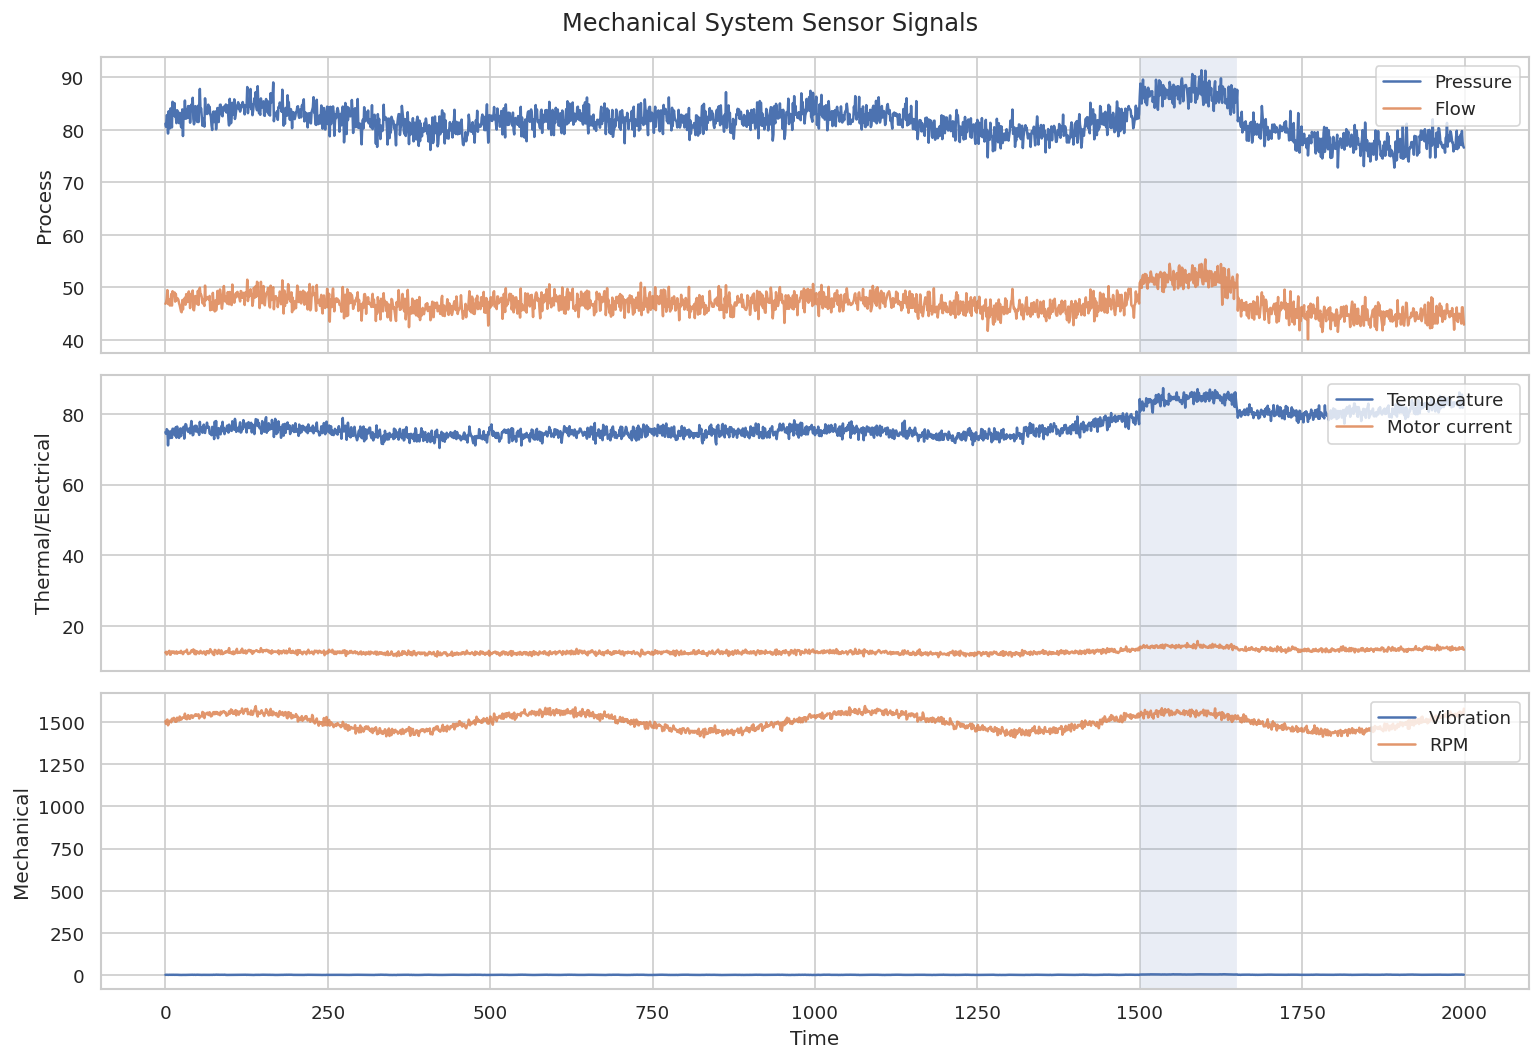

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(df["time"], df["pressure"], label="Pressure")
axes[0].plot(df["time"], df["flow"], label="Flow", alpha=0.85)
axes[0].set_ylabel("Process")
axes[0].legend(loc="upper right")

axes[1].plot(df["time"], df["temperature"], label="Temperature")
axes[1].plot(df["time"], df["motor_current"], label="Motor current", alpha=0.85)
axes[1].set_ylabel("Thermal/Electrical")
axes[1].legend(loc="upper right")

axes[2].plot(df["time"], df["vibration"], label="Vibration")
axes[2].plot(df["time"], df["rpm"], label="RPM", alpha=0.85)
axes[2].set_ylabel("Mechanical")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper right")

for ax in axes:
    ax.axvspan(1500, 1650, alpha=0.12)

fig.suptitle("Mechanical System Sensor Signals")
fig.tight_layout()
plt.show()

## 3.  Correlation analysis

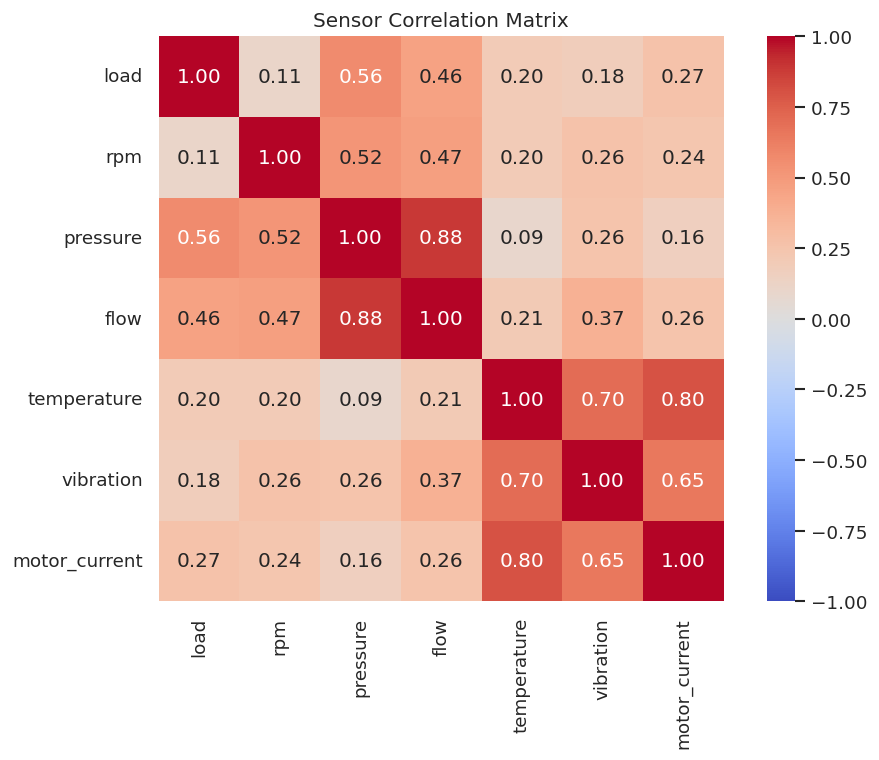

In [8]:
sensor_cols = ["load", "rpm", "pressure", "flow", "temperature", "vibration", "motor_current"]
corr = df[sensor_cols].corr()

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Sensor Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Frequency analysis of vibration

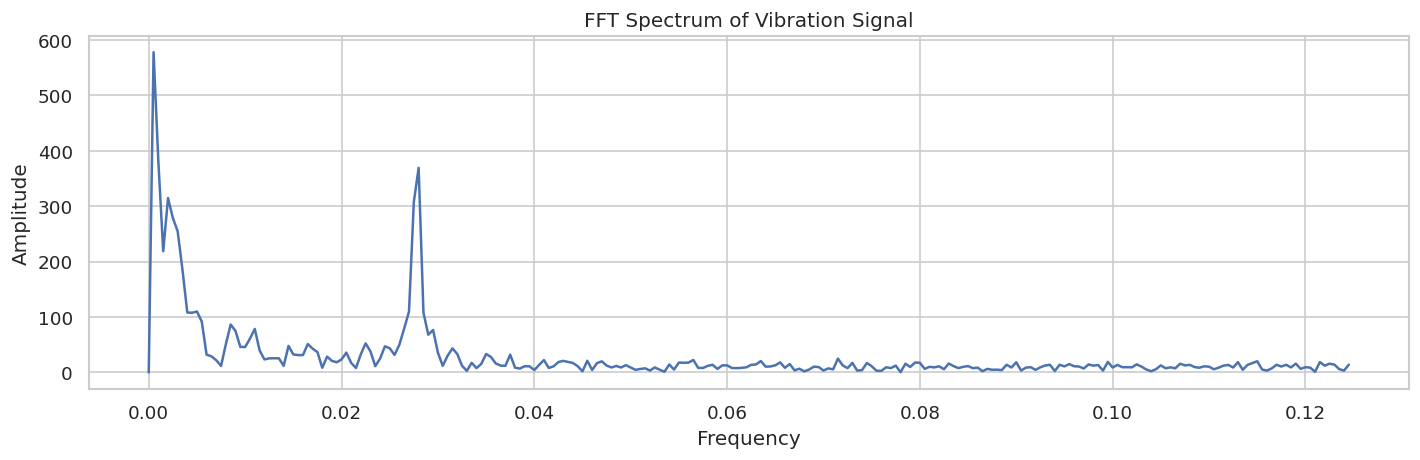

In [9]:
signal = df["vibration"].to_numpy()
sample_spacing = 1.0

fft_values = np.abs(rfft(signal - signal.mean()))
frequencies = rfftfreq(len(signal), d=sample_spacing)

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:250], fft_values[:250])
plt.title("FFT Spectrum of Vibration Signal")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 5.  feature engineer for health monitoring

In [10]:
feature_source = df[sensor_cols].copy()

# Rolling statistics capture local drift and instability
for col in ["pressure", "flow", "temperature", "vibration", "motor_current"]:
    feature_source[f"{col}_roll_mean"] = df[col].rolling(window=25, min_periods=1).mean()
    feature_source[f"{col}_roll_std"] = df[col].rolling(window=25, min_periods=1).std().fillna(0)
    feature_source[f"{col}_diff"] = df[col].diff().fillna(0)

# A simple interpretable health score: higher is healthier
z = (feature_source - feature_source.mean()) / feature_source.std(ddof=0)
health_penalty = (
    1.8 * z["vibration"].abs()
    + 1.2 * z["temperature"].abs()
    + 0.9 * z["motor_current"].abs()
    + 0.8 * z["pressure"].abs()
    + 0.7 * z["flow"].abs()
)
df["health_score"] = np.clip(100 - 8 * health_penalty, 0, 100)

df[["time", "health_score", "fault_window"]].head()

,time,health_score,fault_window
0,0,86.418177,0
1,1,90.394441,0
2,2,81.066318,0
3,3,81.253898,0
4,4,77.734756,0


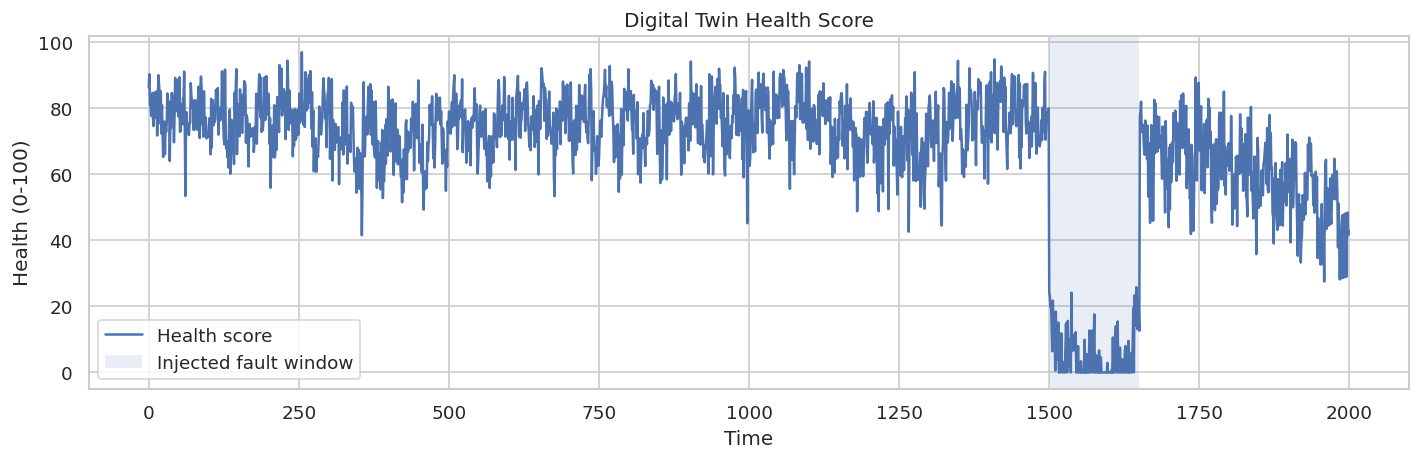

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df["time"], df["health_score"], label="Health score")
plt.axvspan(1500, 1650, alpha=0.12, label="Injected fault window")
plt.title("Digital Twin Health Score")
plt.xlabel("Time")
plt.ylabel("Health (0-100)")
plt.legend()
plt.tight_layout()
plt.show()

## PCA health space

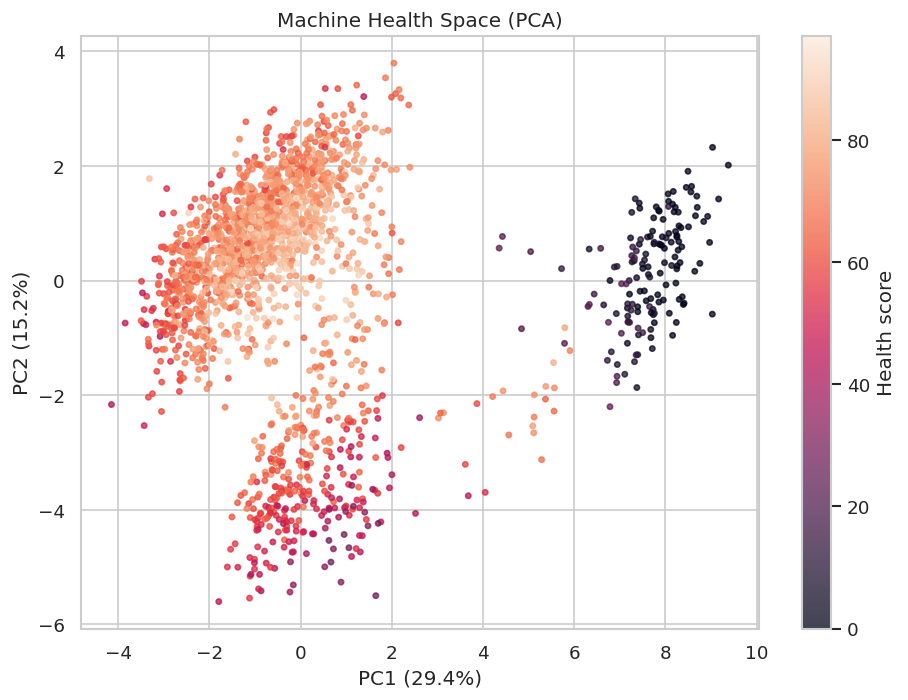

array([0.29430383, 0.15175869])

In [12]:
pca_features = feature_source.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_features)

pca = PCA(n_components=2, random_state=RNG_SEED)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    {
        "pc1": components[:, 0],
        "pc2": components[:, 1],
        "health_score": df["health_score"],
        "fault_window": df["fault_window"],
    }
)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df["pc1"], pca_df["pc2"], c=pca_df["health_score"], s=10, alpha=0.75)
plt.colorbar(scatter, label="Health score")
plt.title("Machine Health Space (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

pca.explained_variance_ratio_

## 7.  Anomaly detection

In [13]:
anomaly_features = scaler.fit_transform(df[sensor_cols])

model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=RNG_SEED
)
df["anomaly_flag"] = model.fit_predict(anomaly_features)
df["anomaly_score"] = -model.score_samples(anomaly_features)  # higher = more anomalous

anomaly_count = int((df["anomaly_flag"] == -1).sum())
anomaly_count

60

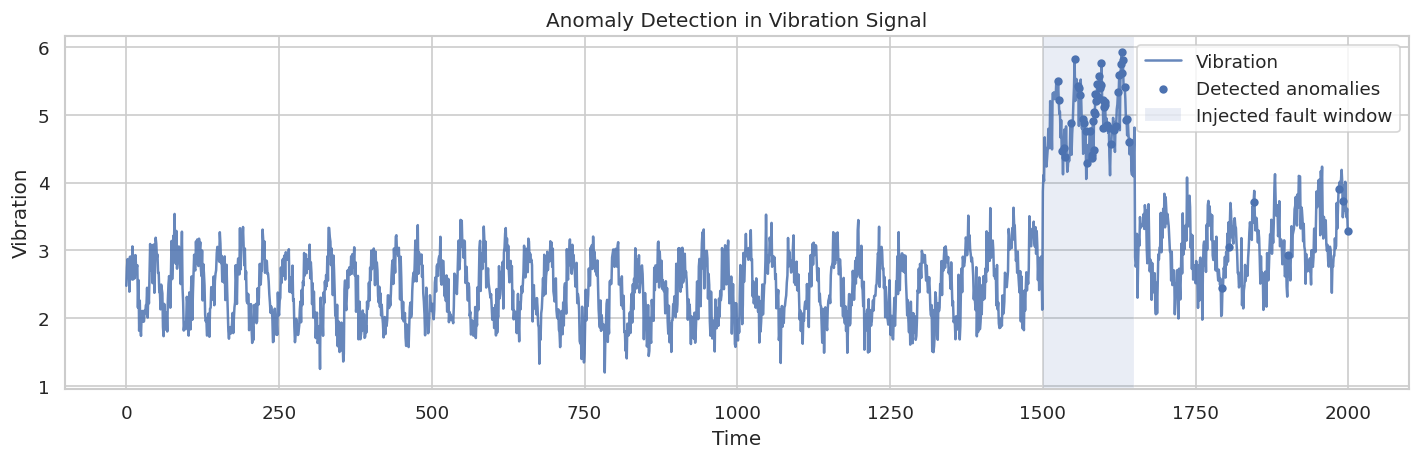

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(df["time"], df["vibration"], label="Vibration", alpha=0.85)
plt.scatter(
    df.loc[df["anomaly_flag"] == -1, "time"],
    df.loc[df["anomaly_flag"] == -1, "vibration"],
    label="Detected anomalies",
    s=16,
)
plt.axvspan(1500, 1650, alpha=0.12, label="Injected fault window")
plt.title("Anomaly Detection in Vibration Signal")
plt.xlabel("Time")
plt.ylabel("Vibration")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
df.loc[df["anomaly_flag"] == -1, ["time", "pressure", "flow", "temperature", "vibration", "motor_current", "health_score"]].head(10)

,time,pressure,flow,temperature,vibration,motor_current,health_score
1525,1525,89.569580,51.950296,85.314140,5.502530,14.461296,0.000000
1526,1526,87.707785,52.549028,83.204408,5.212569,14.528645,0.000000
1532,1532,89.163776,52.942259,82.137021,4.467757,14.567511,1.955497
1534,1534,88.089305,52.677992,84.449400,4.512753,13.826729,5.699710
1536,1536,88.551831,51.817983,87.260495,4.381616,14.143058,0.000000
1546,1546,89.140909,54.492227,84.008014,4.887096,14.267094,0.000000
1552,1552,88.608795,53.132904,84.174432,5.828271,14.035099,0.000000
1557,1557,88.016808,52.718232,86.058532,5.431353,14.053748,0.000000
1560,1560,88.277868,53.880773,84.730181,5.396898,14.639148,0.000000
1561,1561,87.453879,54.178621,83.714084,5.286008,14.511983,0.000000


## 8. Sensor interaction network

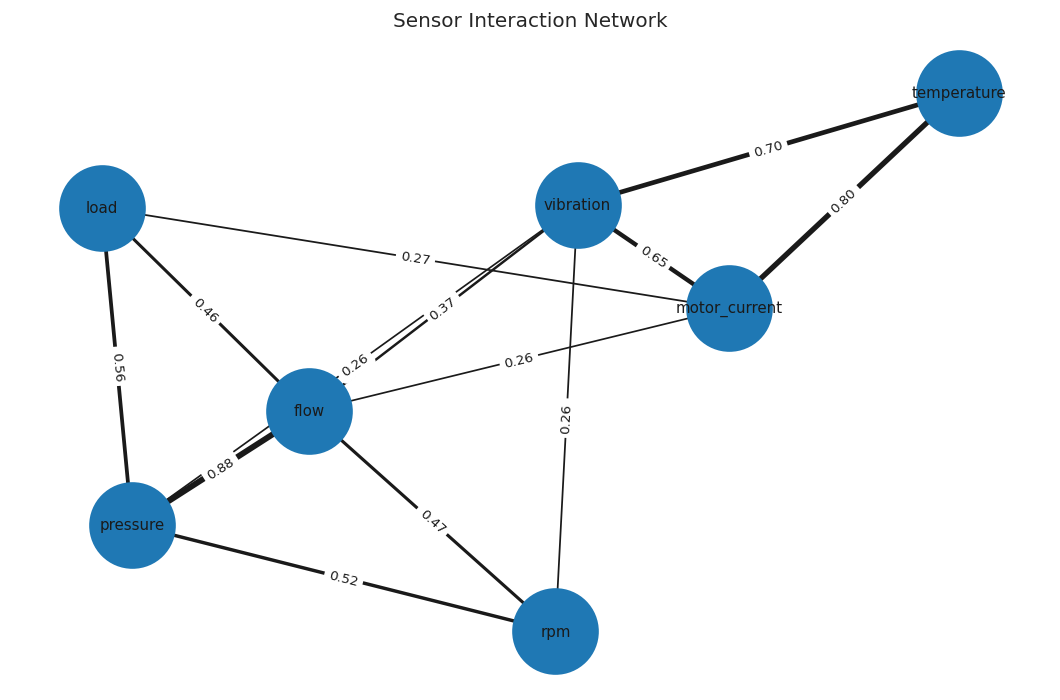

In [16]:
network_corr = df[sensor_cols].corr()

G = nx.Graph()
G.add_nodes_from(sensor_cols)

threshold = 0.25
for i, a in enumerate(sensor_cols):
    for b in sensor_cols[i + 1:]:
        w = network_corr.loc[a, b]
        if abs(w) >= threshold:
            G.add_edge(a, b, weight=w)

pos = nx.spring_layout(G, seed=RNG_SEED, k=1.1)

plt.figure(figsize=(9, 6))
edge_weights = [abs(G[u][v]["weight"]) * 4 for u, v in G.edges()]
edge_labels = {(u, v): f'{G[u][v]["weight"]:.2f}' for u, v in G.edges()}

nx.draw_networkx_nodes(G, pos, node_size=2600)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, width=edge_weights)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Sensor Interaction Network")
plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Mechanical digital twin architecture

/tmp/ipykernel_907/1659182825.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


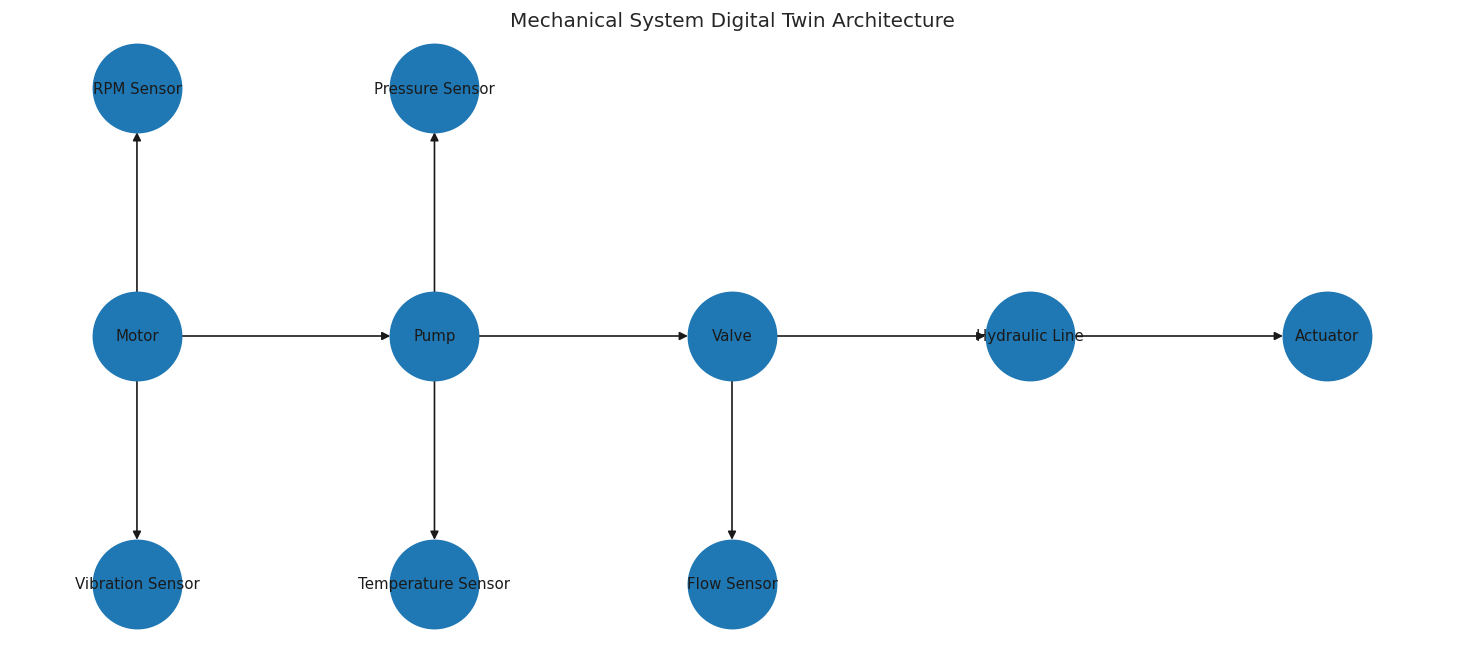

In [17]:
G_sys = nx.DiGraph()

components = ["Motor", "Pump", "Valve", "Hydraulic Line", "Actuator"]
sensors = ["RPM Sensor", "Pressure Sensor", "Flow Sensor", "Temperature Sensor", "Vibration Sensor"]

G_sys.add_nodes_from(components, kind="component")
G_sys.add_nodes_from(sensors, kind="sensor")

G_sys.add_edges_from([
    ("Motor", "Pump"),
    ("Pump", "Valve"),
    ("Valve", "Hydraulic Line"),
    ("Hydraulic Line", "Actuator"),
    ("Motor", "RPM Sensor"),
    ("Motor", "Vibration Sensor"),
    ("Pump", "Pressure Sensor"),
    ("Pump", "Temperature Sensor"),
    ("Valve", "Flow Sensor"),
])

pos = {
    "Motor": (0, 0),
    "Pump": (2, 0),
    "Valve": (4, 0),
    "Hydraulic Line": (6, 0),
    "Actuator": (8, 0),
    "RPM Sensor": (0, 2),
    "Vibration Sensor": (0, -2),
    "Pressure Sensor": (2, 2),
    "Temperature Sensor": (2, -2),
    "Flow Sensor": (4, -2),
}

plt.figure(figsize=(12, 5))
nx.draw(
    G_sys,
    pos,
    with_labels=True,
    node_size=2800,
    arrows=True,
    font_size=9
)
plt.title("Mechanical System Digital Twin Architecture")
plt.axis("off")
plt.tight_layout()
plt.show()

## 10. Operational summary


In [18]:
summary = {
    "samples": len(df),
    "mean_health_score": round(df["health_score"].mean(), 2),
    "min_health_score": round(df["health_score"].min(), 2),
    "detected_anomalies": int((df["anomaly_flag"] == -1).sum()),
    "fault_window_points": int(df["fault_window"].sum()),
    "PCA_variance_explained": round(float(pca.explained_variance_ratio_.sum() * 100), 2),
}

summary_df = pd.DataFrame([summary])
summary_df

,samples,mean_health_score,min_health_score,detected_anomalies,fault_window_points,PCA_variance_explained
0,2000,67.3,0.0,60,151,44.61


In [19]:
top_anomalies = (
    df.loc[df["anomaly_flag"] == -1, ["time", "health_score", "anomaly_score", "temperature", "vibration", "motor_current"]]
      .sort_values("anomaly_score", ascending=False)
      .head(10)
)

top_anomalies

,time,health_score,anomaly_score,temperature,vibration,motor_current
1616,1616,0.0,0.643569,86.679616,4.778130,14.733422
1592,1592,0.0,0.643381,85.002699,5.571381,14.484719
1601,1601,0.0,0.641244,83.446696,5.195397,14.329715
1595,1595,0.0,0.634631,83.547423,5.437782,13.934419
1589,1589,0.0,0.633301,86.985503,5.451407,15.743555
1581,1581,0.0,0.632207,85.805581,4.405290,14.439181
1591,1591,0.0,0.628091,85.935600,5.262473,14.626394
1585,1585,0.0,0.626298,84.089946,5.010704,14.473941
1625,1625,0.0,0.622114,84.822879,5.590186,13.900227
1525,1525,0.0,0.616624,85.314140,5.502530,14.461296


## Notes

This upgraded version is ready for extension into:
- live sensor ingestion
- dashboard deployment
- predictive maintenance classification
- alert thresholds and maintenance scheduling